--- CONSTRUYENDO REGULARIZED TABULAR RESNET (V5) ---
Epoch 1/60
212/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6884 - loss: 1.4375
Epoch 1: val_loss improved from None to 1.27773, saving model to best_resnet_v5_model.keras

Epoch 1: finished saving model to best_resnet_v5_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6907 - loss: 1.4332 - val_accuracy: 0.7752 - val_loss: 1.2777 - learning_rate: 0.0010
Epoch 2/60
195/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7558 - loss: 1.2478
Epoch 2: val_loss improved from 1.27773 to 1.15122, saving model to best_resnet_v5_model.keras

Epoch 2: finished saving model to best_resnet_v5_model.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7547 - loss: 1.2454 - val_accuracy: 0.7786 - val_loss: 1.1512 - learning_rate: 0.0010
Epoch 3/60
209/218 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7732 - loss: 1.1396
Epoch 3: val_loss improved from 1.15122 to 1.05658, saving model to best_resnet_v5_model.keras



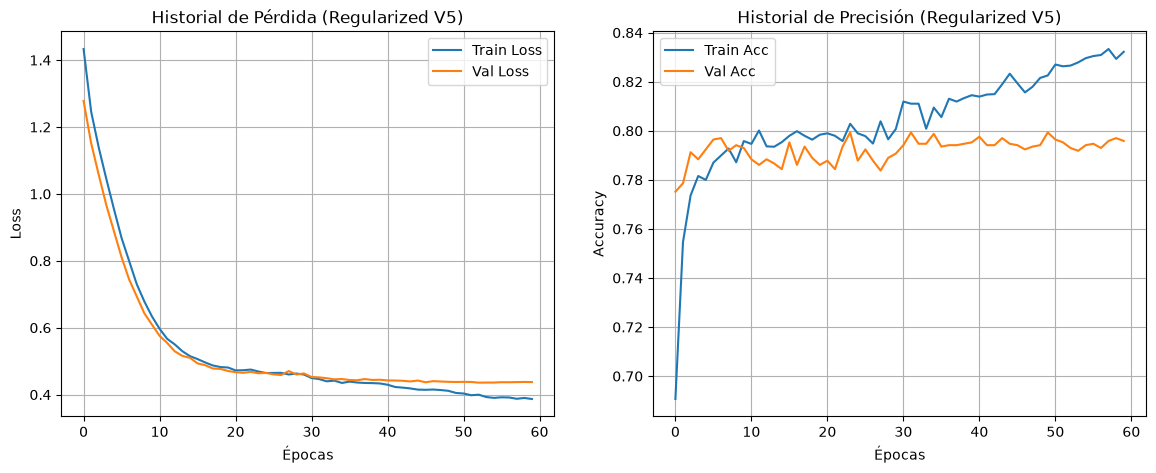


--- GENERANDO SUBMISSION_5.CSV ---
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ ¡Archivo 'submission_5.csv' guardado y optimizado con éxito!
Transported
True     2254
False    2023
Name: count, dtype: int64


In [ ]:
# solution_final_project_5.ipynb - REGULARIZED TABULAR RESNET (V5)

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DE SEMILLAS PARA REPRODUCIBILIDAD ACADÉMICA
np.random.seed(42)
tf.random.set_seed(42)

# Carga de datos
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# 2. PIPELINE DE INGENIERÍA DE VARIABLES (Consistente con versiones previas)
def preprocess_features(df):
    df = df.copy()
    # Gastos consolidados
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df[spend_cols] = df[spend_cols].fillna(0)
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['HasSpented'] = (df['TotalSpend'] > 0).astype(str)
    
    # Datos de grupo y cabina
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0] if pd.notnull(x) else '0000')
    group_sizes = df['Group'].value_counts()
    df['GroupSize'] = df['Group'].map(group_sizes)
    df['IsAlone'] = (df['GroupSize'] == 1).astype(str)
    
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Cabin_Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Cabin_Side'] = df['Cabin'].apply(lambda x: x.split('/')[-1])
    return df

train_processed = preprocess_features(train_df)
test_processed = preprocess_features(test_df)

num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend', 'GroupSize']
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'HasSpented', 'IsAlone']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Splits de validación
X = train_processed[num_features + cat_features]
y = train_processed['Transported'].astype(int).values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
X_test_trans = preprocessor.transform(test_processed[num_features + cat_features])

# 3. DISEÑO DE LA ARQUITECTURA RESIDUAL ALTAMENTE REGULARIZADA

print("--- CONSTRUYENDO REGULARIZED TABULAR RESNET (V5) ---")

input_dim = X_train_trans.shape[1]
inputs = layers.Input(shape=(input_dim,), name="Input_Features")

# Factor de regularización L2 más restrictivo
l2_reg = keras.regularizers.l2(0.0015)

# Capa de proyección inicial
x = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)  # Incrementado de 0.3 a 0.4 para combatir overfitting

# --- BLOQUE RESIDUAL 1 (128 Neuronas) ---
res1 = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(x)
res1 = layers.BatchNormalization()(res1)
res1 = layers.Dropout(0.4)(res1)
res1 = layers.Dense(128, activation='relu', kernel_regularizer=l2_reg)(res1)
res1 = layers.BatchNormalization()(res1)
x = layers.add([x, res1]) 

# --- BLOQUE RESIDUAL 2 (64 Neuronas) ---
x_proj = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x)
x_proj = layers.BatchNormalization()(x_proj)

res2 = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(x_proj)
res2 = layers.BatchNormalization()(res2)
res2 = layers.Dropout(0.3)(res2)
res2 = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(res2)
res2 = layers.BatchNormalization()(res2)
x = layers.add([x_proj, res2])

# --- CAPA DE SALIDA CON REGULARIZACIÓN SÓLIDA ---
x = layers.Dense(32, activation='relu', kernel_regularizer=l2_reg)(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(1, activation='sigmoid', name="Output_Layer")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="Regularized_Tabular_ResNet")

# 4. ENTRENAMIENTO CON OPTIMIZACIÓN SUAVE

# Learning rate inicial de 0.001 (más conservador que el 0.003 de la v4)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback para guardar el mejor modelo absoluto basándose en la pérdida de validación
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_resnet_v5_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

lr_decay = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    verbose=1,
    min_lr=1e-5
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    X_train_trans, y_train,
    validation_data=(X_val_trans, y_val),
    epochs=60,
    batch_size=32,
    callbacks=[early_stopping, lr_decay, checkpoint],
    verbose=1
)

# 5. GRAFICAR CURVAS DE APRENDIZAJE PARA EL REPORTE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Historial de Pérdida (Regularized V5)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Historial de Precisión (Regularized V5)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.savefig('learning_curves_v5.png')
plt.show()

# 6. GENERACIÓN DEL ARCHIVO SUBMISSION_5.CSV

print("\n--- GENERANDO SUBMISSION_5.CSV ---")
# Cargamos los mejores pesos guardados durante el entrenamiento
model.load_weights('best_resnet_v5_model.keras')

test_preds_proba = model.predict(X_test_trans)
test_preds_boolean = (test_preds_proba > 0.5).astype(bool).flatten()

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds_boolean
})

submission_df.to_csv('submission_5.csv', index=False)
print("✅ ¡Archivo 'submission_5.csv' guardado y optimizado con éxito!")
print(submission_df['Transported'].value_counts())